In [27]:
import sys
import pandas as pd
import numpy as np
from multiprocessing import Pool
from plotnine import *
import plotnine as plt

PATH = "/home/jmurga/mkt/202004" 
sys.path.insert(0, PATH + '/scripts/src/')  
from pyAmkt import *
from slimParser import *

In [7]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [2]:
!which julia

/home/jmurga/julia-1.5.3/bin/julia


In [8]:
!julia $PATH/scripts/src/julia_dependencies.jl

   Updating git-repo `https://github.com/jmurga/Analytical.jl`
Fetching: [>                                        ]  0.0 %   Updating registry at `~/.julia/registries/General`
######################################################################## 100.0%
  Resolving package versions...
Updating `~/.julia/environments/v1.5/Project.toml`
  [1f0a6972] ~ Analytical v0.2.0 `https://github.com/jmurga/Analytical.jl#master` ⇒ v0.2.0 `https://github.com/jmurga/Analytical.jl#master`
Updating `~/.julia/environments/v1.5/Manifest.toml`
  [1f0a6972] ~ Analytical v0.2.0 `https://github.com/jmurga/Analytical.jl#master` ⇒ v0.2.0 `https://github.com/jmurga/Analytical.jl#master`
  Resolving package versions...
No Changes to `~/.julia/environments/v1.5/Project.toml`
No Changes to `~/.julia/environments/v1.5/Manifest.toml`
  Resolving package versions...
No Changes to `~/.julia/environments/v1.5/Project.toml`
No Changes to `~/.julia/environments/v1.5/Manifest.toml`
  Resolving package versions...
No Cha

# No demography simulations

Create the output directory. You should change the directory tree if you clone the github repo

In [ ]:
!mkdir -p $PATH/rawData/simulations/slim/noDemog $PATH/results/simulations/slim/noDemog

## Solving values to simulate with Analytical.jl

In [ ]:
!julia /home/jmurga/mkt/202004/scripts/src/simTable.jl 500 200000 bgsTable

In [8]:
simTable = pd.read_csv(PATH + "/rawData/simulations/bgsTable.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)
simTable['analysis']= 'noDemog'

I test two cases in the notebook case I select one row from simTable

## Running SLiM

Generating replicates and folders. The simulations were performed using HPC and slurm scheduler

In [16]:
# sbatch bgsSlurm.sh
!cat $PATH/scripts/src/bgsSlurm.sh

#!/bin/bash

#SBATCH --partition=standard
#SBATCH --nodes=4
#SBATCH --ntasks-per-node=50
#SBATCH --ntasks=200
#SBATCH --mem-per-cpu=2GB
#SBATCH --job-name=noDemog
#SBATCH --time=12:00:00
#SBATCH --mail-type=ALL
#SBATCH --mail-user=jesus.murga@uab.cat

DPATH="/xdisk/denard/mig2020/rsgrps/denard"

module load slim
module load parallel

# Each command takes about 12hours to run using this configuration

##########BGS 0.2
seq 1 50000 | parallel -u -j200 "slim -d sampleSize=661 -d codingLength=2000  -d weaklyStrength=10 -d strongStrength=500 -d bgsMutationRate=5.1471e-8 -d pposL=0.01153603001 -d pposH=7.9479354e-5 -d p=\'${DPATH}/jmurga/simulations/isolation/isolation_0.4_0.1_0.2\' -d nF={} ${DPATH}/jmurga/src/bgs.slim"
seq 1 50000 | parallel -u -j200 "slim -d sampleSize=661 -d codingLength=2000  -d weaklyStrength=10 -d strongStrength=500 -d bgsMutationRate=5.1471e-8 -d pposL=0.01153603001 -d pposH=7.9479354e-5 -d p=\'${DPATH}/jmurga/simulations/isolation/isolation_0.4_0.2_0.2\' -d nF={} ${

## Processing simulated data

### All simulations

We bootstrap the data to get 100 observed dataset

In [60]:
for index,row in simTable.iterrows():
    print(row.path)
    parseBootstrapPolDiv(path=row.path,N=500,nthreads=8,replicas=100,sample=1)


/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.999


100%|██████████| 50000/50000 [01:27<00:00, 572.92it/s]


In [9]:
df,dfAlpha = saveSimulatedAlphas(simTable,h=1);dfAlpha
df_v2,dfAlpha_v2 = saveSimulatedAlphas(simTable,h=0.9);dfAlpha
df = df.round(3);df

,trueAlpha,asymp_nopos,asymp,analyticalEstimation,path,analysis
0,0.193,0.153,0.126,0.257,noDemog_0.4_0.1_0.2,noDemog
0,0.177,0.108,0.052,0.231,noDemog_0.4_0.2_0.2,noDemog
0,0.161,0.167,0.074,0.203,noDemog_0.4_0.3_0.2,noDemog
0,0.273,0.223,0.185,0.313,noDemog_0.4_0.1_0.4,noDemog
0,0.256,0.188,0.110,0.296,noDemog_0.4_0.2_0.4,noDemog
0,0.238,0.140,0.026,0.277,noDemog_0.4_0.3_0.4,noDemog
0,0.369,0.359,0.314,0.379,noDemog_0.4_0.1_0.8,noDemog
0,0.352,0.314,0.222,0.374,noDemog_0.4_0.2_0.8,noDemog
0,0.335,0.295,0.160,0.370,noDemog_0.4_0.3_0.8,noDemog
0,0.401,0.371,0.322,0.401,noDemog_0.4_0.1_0.999,noDemog


Plotting in R

In [26]:
%%R -i PATH -i dfAlpha -i dfAlpha_v2 -i df -i df_v2 -o p1 -o p2

p1 = plotSimulatedAlphas(df = dfAlpha,trues=df,title= "Non-demography simulations",output = paste0(PATH,'/results/simulations/slim/noDemog/noDemogSimulatedAlphas.svg'))
p2 = plotSimulatedAlphas(df = dfAlpha_v2,trues=df,title= "Non-demography simulations. Frequency cutoff = 0.9",output = paste0(PATH,'/results/simulations/slim/noDemog/noDemogSimulatedAlphasCutoff.svg'))

R[write to console]: Saving 6.67 x 6.67 in image

R[write to console]: Saving 6.67 x 6.67 in image

R[write to console]: Saving 6.67 x 6.67 in image

R[write to console]: Saving 6.67 x 6.67 in image



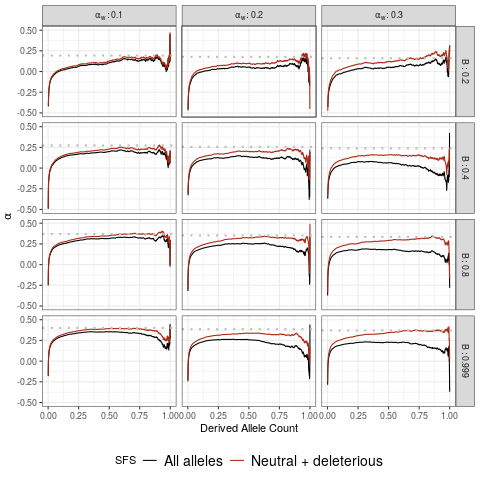

In [22]:
%%R
p1

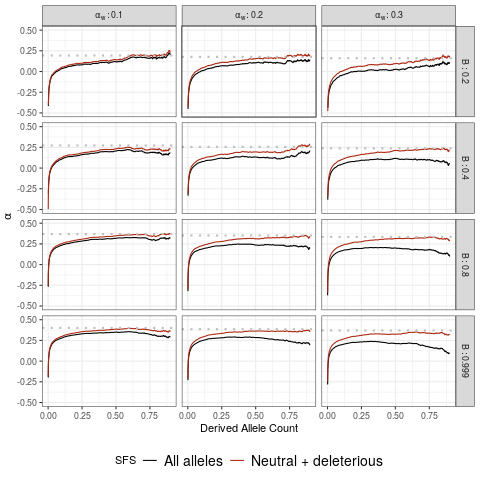

In [23]:
%%R 
p2

Saving files

In [24]:
df.to_csv(PATH + '/results/simulations/slim/noDemog/noDemoSsimulatedAlphas.tsv',index=False,sep='\t',header=True)
df_v2.to_csv(PATH + '/results/simulations/slim/noDemog/noDemogSimulatedAlphasCutoff.tsv',index=False,sep='\t',header=True)

In [25]:
dfAlpha.to_csv(PATH + '/results/simulations/slim/noDemog/noDemogSimulatedToPlotAll.tsv',index=False,sep='\t',header=True)
dfAlpha_v2.to_csv(PATH + '/results/simulations/slim/noDemog/noDemogSimulatedToPlotAllCutoff.tsv',index=False,sep='\t',header=True)

### Convert SFS to DOFE and bootstrap

In [7]:
for index, row in simTable.iterrows():
    print(row.path)
    parseBootstrapPolDiv(path=row.path,N=500,output="/home/jmurga/mkt/202004/rawData/noDemog1000/",sample=50000,replicas=100,dofe=False,bins=500,nthreads=8)

'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.2'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.2'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.2'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.4'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.4'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.4'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.8'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.8'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.8'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.1_0.999'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.2_0.999'
'/home/jmurga/mkt/202004/rawData/simulations/noDemog/ne500/noDemog_0.4_0.3_0.999'


# Tennesen model. African population in isolation

Create the output directory. You should change the directory tree if you clone the github repo

In [ ]:
!mkdir -p $PATH/rawData/simulations/slim/isolation $PATH/results/simulations/slim/isolation

## Solving values to simulate with Analytical.jl

In [ ]:
!julia /home/jmurga/mkt/202004/scripts/src/simTable.jl 7310 200000 tennensen.tsv

In [28]:
simTable = pd.read_csv(PATH + "/rawData/simulations/tennesen.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/isolation/isolation_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)
simTable['analysis'] = 'isolation'

## Running SLiM

Generating replicates and folders. The simulations were performed using HPC and slurm scheduler

In [32]:
# sbatch bgsSlurm.sh
!cat $PATH/scripts/src/isolationSlurm.sh

#!/bin/bash

#SBATCH --partition=standard
#SBATCH --nodes=4
#SBATCH --ntasks=200
#SBATCH --ntasks-per-node=50
#SBATCH --mem-per-cpu=2GB
#SBATCH --job-name=isolation
#SBATCH --time=24:00:00
#SBATCH --mail-type=ALL

DPATH="/xdisk/denard/mig2020/rsgrps/denard"
module load slim
module load parallel

# Each command takes about 24hours to run using this configuration

##########BGS 0.2
seq 1 50000 | parallel -u -j200 "slim -d sampleSize=661 -d codingLength=2000  -d weaklyStrength=10 -d strongStrength=500 -d bgsMutationRate=5.1471e-8 -d pposL=0.01153603001 -d pposH=7.9479354e-5 -d p=\'${DPATH}/jmurga/simulations/isolation/isolation_0.4_0.1_0.2\' -d nF={} ${DPATH}/jmurga/src/isolation.slim"
seq 1 50000 | parallel -u -j200 "slim -d sampleSize=661 -d codingLength=2000  -d weaklyStrength=10 -d strongStrength=500 -d bgsMutationRate=5.1471e-8 -d pposL=0.01153603001 -d pposH=7.9479354e-5 -d p=\'${DPATH}/jmurga/simulations/isolation/isolation_0.4_0.2_0.2\' -d nF={} ${DPATH}/jmurga/src/isolation.slim"

## Processing simulated data

We bootstrap the replicas to get 100 observed dataset

In [ ]:
for index,row in simTable.iterrows():
    parseBootstrapPolDiv(path=row.path,N=(661*2)-1,output=row.path,sample=1,replicas=100,nthreads=8,dofe=False,bins=None)

In [29]:
df,dfAlpha = saveSimulatedAlphas(simTable,h=1);dfAlpha
df = df.round(3)
df_v2,dfAlpha_v2 = saveSimulatedAlphas(simTable,h=0.9);dfAlpha
df_v2 = df.round(3)

In [12]:
df

,trueAlpha,asymp_nopos,asymp,analyticalEstimation,path,analysis
0,0.209,0.156,0.117,0.257,isolation_0.4_0.1_0.2,isolation
0,0.191,0.197,0.121,0.231,isolation_0.4_0.2_0.2,isolation
0,0.176,0.161,0.046,0.203,isolation_0.4_0.3_0.2,isolation
0,0.252,0.220,NaN,0.313,isolation_0.4_0.1_0.4,isolation
0,0.265,0.227,0.054,0.295,isolation_0.4_0.2_0.4,isolation
0,0.251,0.249,0.099,0.277,isolation_0.4_0.3_0.4,isolation
0,0.359,0.311,0.253,0.379,isolation_0.4_0.1_0.8,isolation
0,0.351,0.327,NaN,0.374,isolation_0.4_0.2_0.8,isolation
0,0.342,0.321,NaN,0.370,isolation_0.4_0.3_0.8,isolation
0,0.390,0.353,0.291,0.401,isolation_0.4_0.1_0.999,isolation


In [30]:
%%R -i PATH -i dfAlpha -i dfAlpha_v2 -i df -i df_v2 -o p1 -o p2

source(paste0(PATH,'/scripts/src/plot.R'));

p1 = plotSimulatedAlphas(df = dfAlpha,trues=df,title= "Tennesen simulations",output = paste0(PATH,'/results/simulations/slim/isolation/tennesenSimulatedAlphas.svg'))
p2 = plotSimulatedAlphas(df = dfAlpha_v2,trues=df,title= "Tennesen simulations. Frequency cutoff = 0.9",output = paste0(PATH,'/results/simulations/slim/isolation/tennesenSimulatedAlphasCutoff.svg'))

p1 = plotSimulatedAlphas(df = dfAlpha,trues=df,title= "Tennesen simulations",output = paste0(PATH,'/results/simulations/slim/isolation/tennesenSimulatedAlphas.png'))
p2 = plotSimulatedAlphas(df = dfAlpha_v2,trues=df,title= "Tennesen simulations. Frequency cutoff = 0.9",output = paste0(PATH,'/results/simulations/slim/isolation/tennesenSimulatedAlphasCutoff.png'))

R[write to console]: Saving 6.67 x 6.67 in image

R[write to console]: Saving 6.67 x 6.67 in image

R[write to console]: Saving 6.67 x 6.67 in image

R[write to console]: Saving 6.67 x 6.67 in image



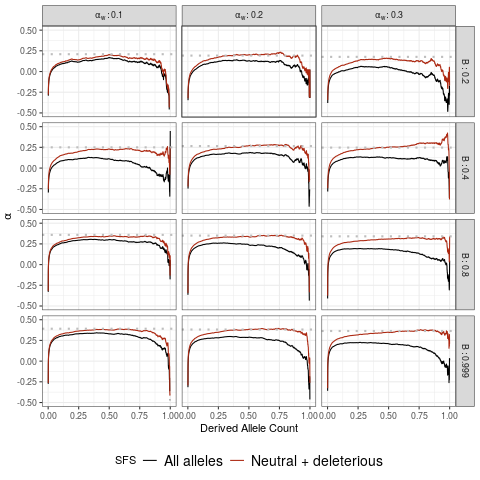

In [31]:
%%R
p1

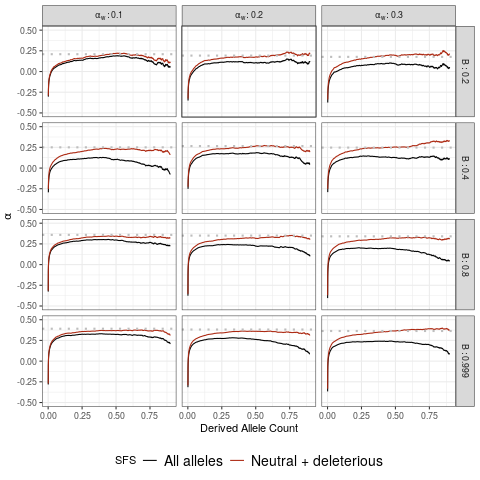

In [32]:
%%R
p2

Saving files

In [15]:
df.to_csv(PATH + '/results/simulations/slim/tennesen/simulatedAlphas.tsv',index=False,sep='\t',header=True)
df_v2.to_csv(PATH + '/results/simulations/slim/tennesen/simulatedAlphasCutoff.tsv',index=False,sep='\t',header=True)

In [16]:
dfAlpha.to_csv(PATH + '/results/simulations/slim/tennesen/simulatedToPlotAll.tsv',index=False,sep='\t',header=True)
dfAlpha_v2.to_csv(PATH + '/results/simulations/slim/tennesen/simulatedToPlotAllCutoff.tsv',index=False,sep='\t',header=True)